In [1]:
# Verify library versions
import tdt
import neurokit2 as nk
from neurokit2 import signal_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import signal_processing as sp
import importlib

print("TDT version:", tdt.__version__)
print("NeuroKit2 version:", nk.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

TDT version: 0.6.6
NeuroKit2 version: 0.2.10
NumPy version: 1.26.4
Pandas version: 2.2.3
Matplotlib version: 3.10.0


### Replace these paths with the ones on your local computer

In [2]:
# b stands for bully, c for cagemate

subj_11_c_path = r'C:\Users\tomhu\Desktop\Code\respiratory_pilot\Data\sub_11_12\copies\subj11-cagemate\subj11-250227-071133'

subj_11_c = tdt.read_block(subj_11_c_path)


print(subj_11_c)


Found Synapse note file: C:\Users\tomhu\Desktop\Code\respiratory_pilot\Data\sub_11_12\copies\subj11-cagemate\subj11-250227-071133\Notes.txt
read from t=0s to t=308.64s
epocs	[struct]
snips	[struct]
streams	[struct]
scalars	[struct]
info	[struct]
time_ranges:	array([[ 0.],
       [inf]])


### Extracting attributes for subj_11_cully

In [3]:
subj_11_c_resp_stream = subj_11_c.streams['Resp']

subj_11_c_resp_data = subj_11_c_resp_stream.data
subj_11_c_resp_size = subj_11_c_resp_data.shape[0]

subj_11_c_resp_fs = subj_11_c_resp_stream.fs
subj_11_c_resp_start_time = subj_11_c_resp_stream.start_time
subj_11_c_resp_data_shape = subj_11_c_resp_stream.data.shape
subj_11_c_resp_size = subj_11_c_resp_data.shape[0]
subj_11_c_resp_channel = subj_11_c_resp_stream.channel
subj_11_c_resp_stream_name = subj_11_c_resp_stream.name



### Finding duration of data in seconds and minutes

In [4]:
print(f"Sampling frequency (fs): {subj_11_c_resp_fs} Hz")
print(f"Size: {subj_11_c_resp_size}")

# Compute total duration in seconds
total_duration = subj_11_c_resp_size / subj_11_c_resp_fs  

# Convert to minutes
total_duration_minutes = total_duration / 60  

print(f"Total duration of respiratory data: {total_duration} seconds ({total_duration_minutes} minutes)")

Sampling frequency (fs): 305.17578125 Hz
Size: 94144
Total duration of respiratory data: 308.4910592 seconds (5.1415176533333335 minutes)


### Filtering respiratory data

In [5]:
# Apply the custom filtering logic
subj_11_c_rsp_cleaned = nk.signal_filter(
    subj_11_c_resp_data,  # Input signal
    lowcut=0.1,   # Low cutoff frequency (Hz)
    highcut=20,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=subj_11_c_resp_fs,  # Sampling rate
    order=2  # Filter order
)

### Resiratory Data Array

In [6]:
subj_11_c_rsp_cleaned

array([-0.01761706, -0.02324762, -0.02888189, ...,  0.09195347,
        0.08209244,  0.0722134 ])

### Plotting entire cleaned subj11 bully resp signal

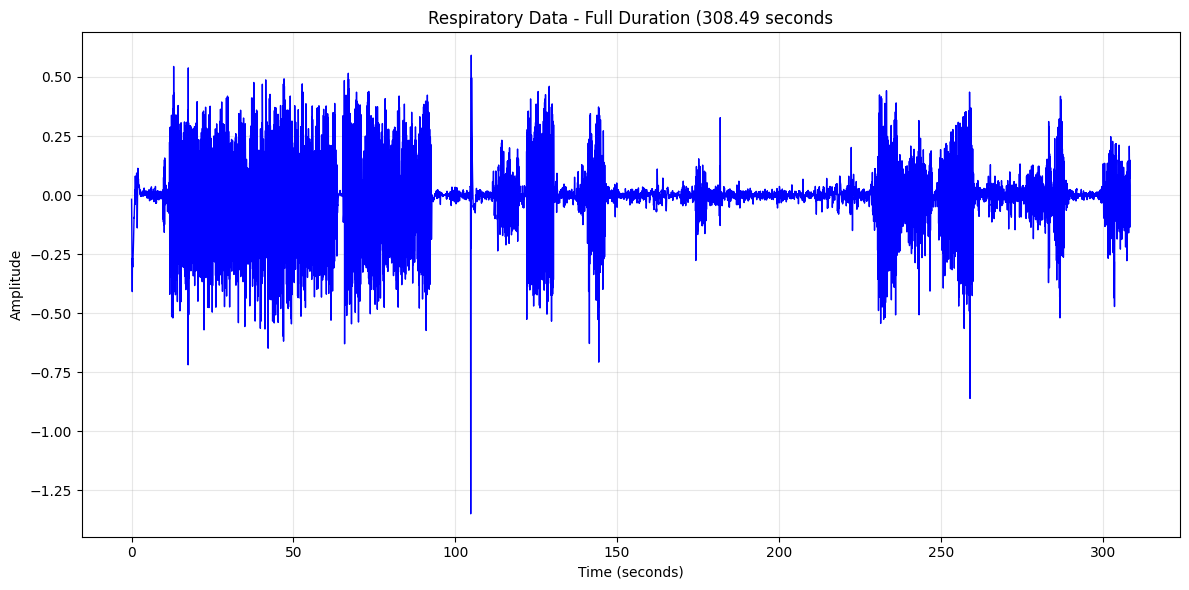

In [7]:
n_samples = len(subj_11_c_rsp_cleaned)

# Create time array for x-axis
time = np.arange(n_samples) / subj_11_c_resp_fs + subj_11_c_resp_start_time

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(time, subj_11_c_rsp_cleaned, 'b-', linewidth=1) 

# Add labels and title
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title(f'Respiratory Data - Full Duration ({n_samples/subj_11_c_resp_fs:.2f} seconds')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

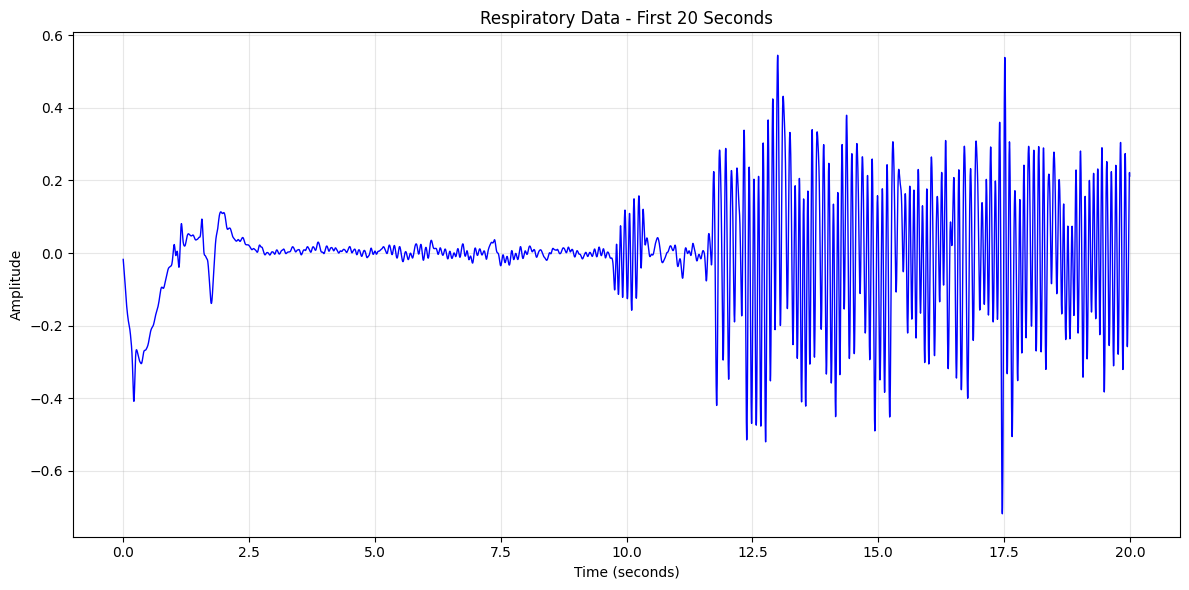

In [8]:
n_samples = int(20 * subj_11_c_resp_fs)  # Number of samples for 10 seconds

# Create time array for x-axis
time = np.arange(n_samples) / subj_11_c_resp_fs + subj_11_c_resp_start_time

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(time, subj_11_c_rsp_cleaned[:n_samples], 'b-', linewidth=1)

# Add labels and title
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title(f'Respiratory Data - First {20} Seconds')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

In [9]:
print(subj_11_c_resp_start_time)

0.0


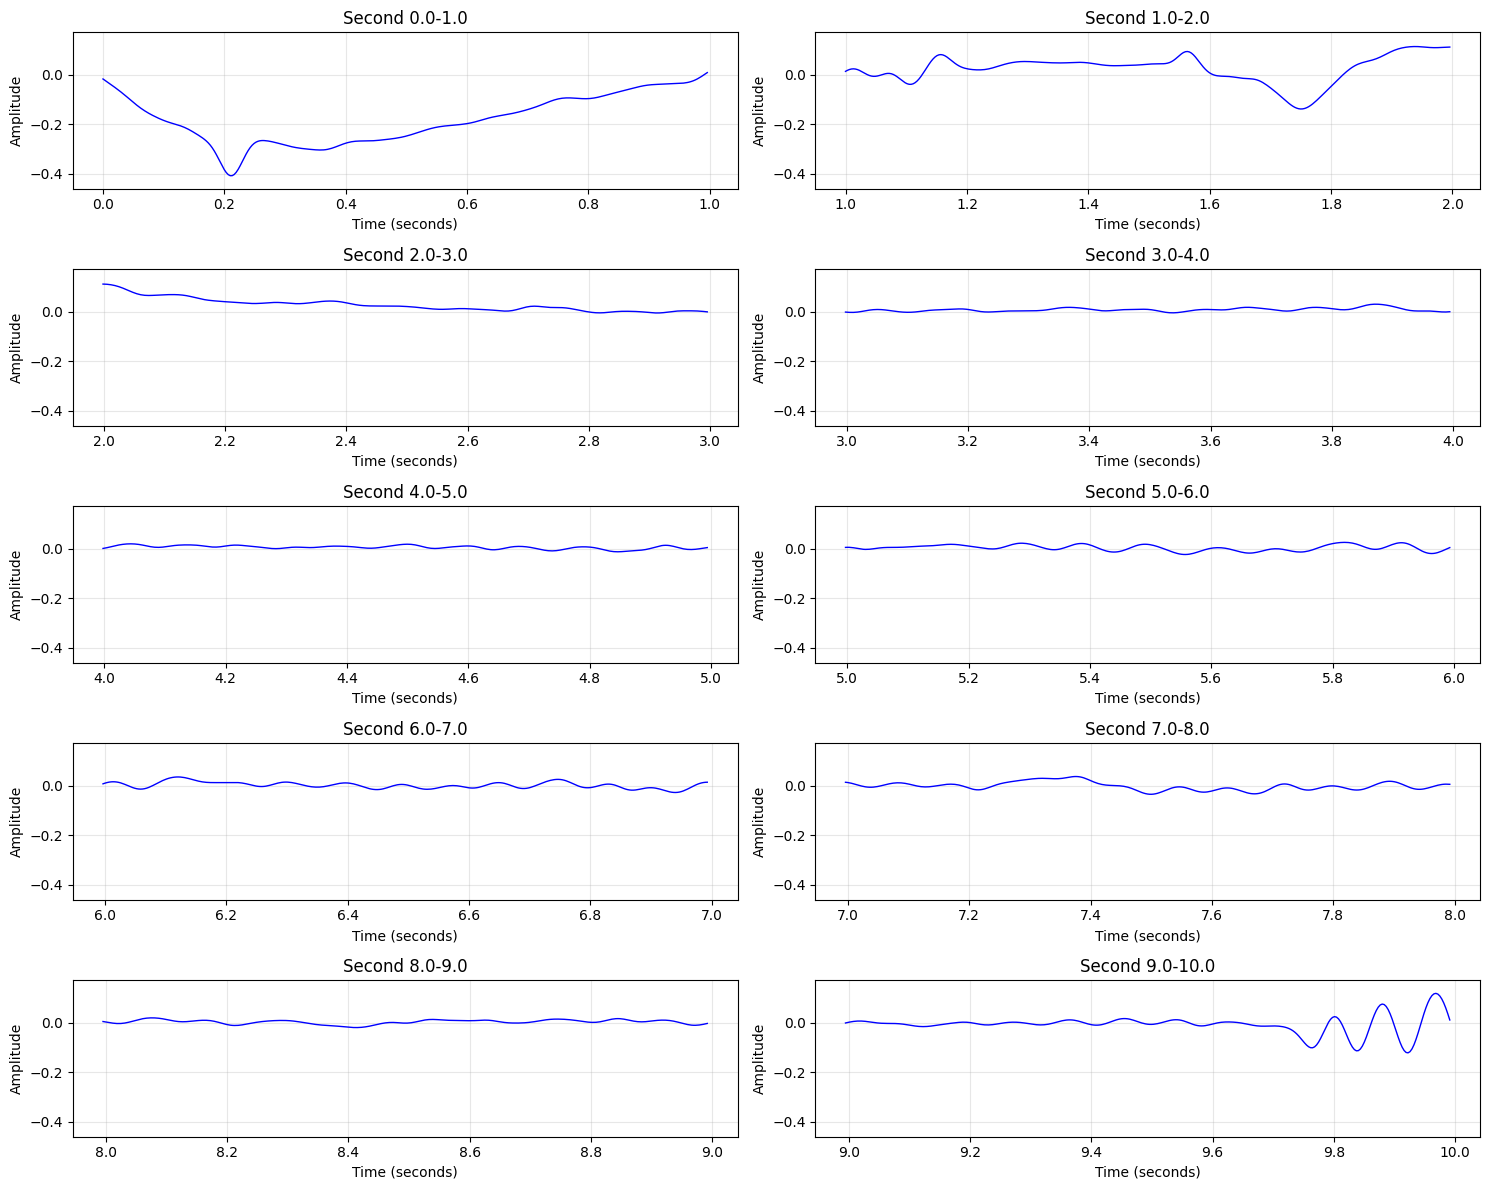

In [10]:
import resp_plotting
import importlib
importlib.reload(resp_plotting)

resp_plotting.plot_respiratory_data_by_second(subj_11_c_rsp_cleaned, subj_11_c_resp_fs, subj_11_c_resp_start_time)

### Creating dataframe for resp signal and boris data

In [15]:
# Generate timestamps
timestamps = np.arange(0, total_duration, 1/subj_11_c_resp_fs)  # Create time axis

# Create the respiration dataframe
resp_df = pd.DataFrame({
    "Timestamp (s)": timestamps,
    "Respiration Value": subj_11_c_rsp_cleaned,
    "Behavioral Event": np.nan  # To be filled later from BORIS mapping
})


resp_df.head()

,Timestamp (s),Respiration Value,Behavioral Event
0,0.000000,-0.017617,NaN
1,0.003277,-0.023248,NaN
2,0.006554,-0.028882,NaN
3,0.009830,-0.034538,NaN
4,0.013107,-0.040235,NaN


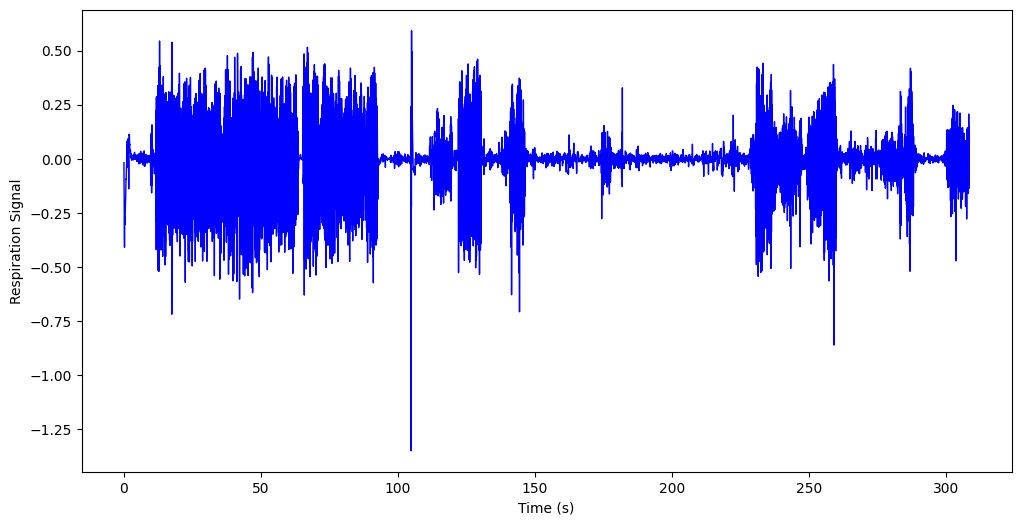

In [16]:
# Plot data
plt.figure(figsize=(12, 6))
plt.plot(resp_df["Timestamp (s)"], resp_df["Respiration Value"], 'b-', linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal")
plt.show()

In [17]:
boris_path = r'C:\Users\tomhu\Desktop\Code\respiratory_pilot\BorisData\sequioaBoris\subject_11_cagemate_AE.csv'

boris_data = pd.read_csv(boris_path)
boris_data.head()

,Observation id,Observation date,Description,Media file,Total length,FPS,Subject,Behavior,Behavioral category,Modifiers,Behavior type,Start (s),Stop (s),Duration (s),Comment start,Comment stop
0,subject_11_cagemate,2025-03-02 18:31:11,NaN,/Users/ayushjain/Downloads/nasal_test-241015-0...,308.6,10.0,subject,anogenital sniffing,NaN,NaN,STATE,9.880,13.605,3.725,NaN,NaN
1,subject_11_cagemate,2025-03-02 18:31:11,NaN,/Users/ayushjain/Downloads/nasal_test-241015-0...,308.6,10.0,subject,chasing,NaN,NaN,STATE,13.803,15.855,2.052,NaN,NaN
2,subject_11_cagemate,2025-03-02 18:31:11,NaN,/Users/ayushjain/Downloads/nasal_test-241015-0...,308.6,10.0,subject,anogenital sniffing,NaN,NaN,STATE,25.380,27.201,1.821,NaN,NaN
3,subject_11_cagemate,2025-03-02 18:31:11,NaN,/Users/ayushjain/Downloads/nasal_test-241015-0...,308.6,10.0,subject,anogenital sniffing,NaN,NaN,STATE,31.454,33.055,1.601,NaN,NaN


In [18]:
boris_data = boris_data[['Behavior', 'Start (s)', 'Stop (s)']]
boris_data.head()

,Behavior,Start (s),Stop (s)
0,anogenital sniffing,9.880,13.605
1,chasing,13.803,15.855
2,anogenital sniffing,25.380,27.201
3,anogenital sniffing,31.454,33.055


In [19]:
# Iterate over BORIS events and map behaviors onto respiration timestamps
for _, row in boris_data.iterrows():
    start_time = row["Start (s)"]
    stop_time = row["Stop (s)"]
    behavior = row["Behavior"]

    # Mask: Find respiration timestamps that fall within the behavior window
    mask = (resp_df["Timestamp (s)"] >= start_time) & (resp_df["Timestamp (s)"] <= stop_time)

    # Assign the behavior to matching respiration timestamps
    resp_df.loc[mask, "Behavioral Event"] = behavior

# Reset start_time
start_time = 0

C:\Users\tomhu\AppData\Local\Temp\ipykernel_45612\3689120803.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'anogenital sniffing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  resp_df.loc[mask, "Behavioral Event"] = behavior


In [20]:
# Around when behavior first starts
resp_df[(resp_df["Timestamp (s)"] >= 11)].head(10)

,Timestamp (s),Respiration Value,Behavioral Event
3357,11.000218,-0.022103,anogenital sniffing
3358,11.003494,-0.026720,anogenital sniffing
3359,11.006771,-0.030585,anogenital sniffing
3360,11.010048,-0.033589,anogenital sniffing
3361,11.013325,-0.035677,anogenital sniffing
3362,11.016602,-0.036851,anogenital sniffing
3363,11.019878,-0.037159,anogenital sniffing
3364,11.023155,-0.036683,anogenital sniffing
3365,11.026432,-0.035530,anogenital sniffing
3366,11.029709,-0.033823,anogenital sniffing


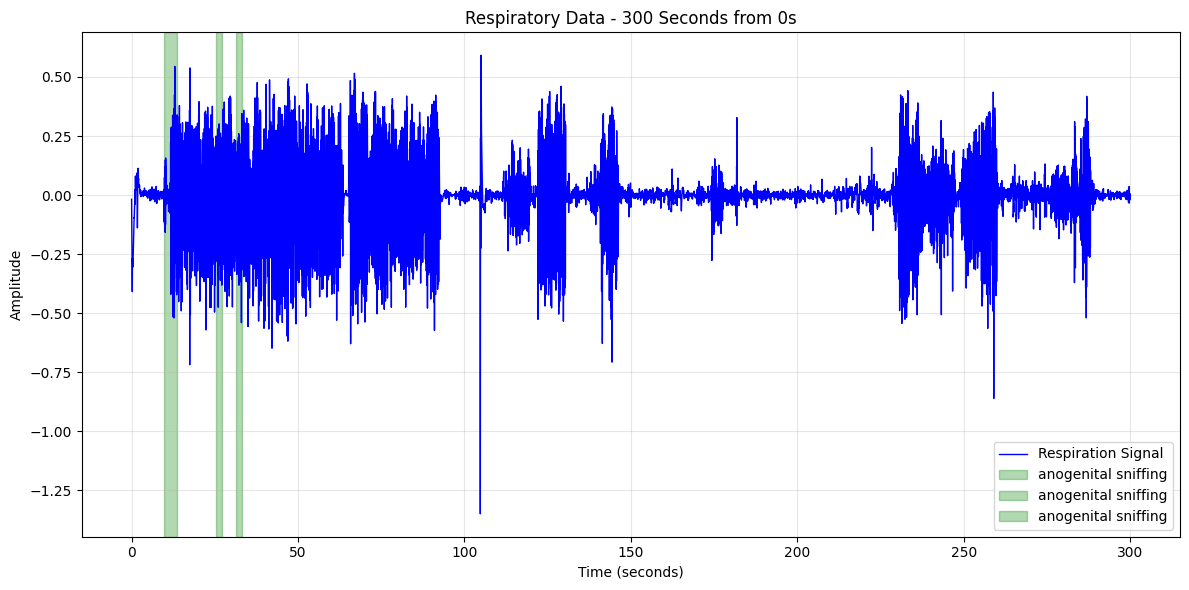

In [21]:
resp_plotting.resp_behavior_plot(resp_df, subj_11_c_resp_fs, start_time, duration=300)

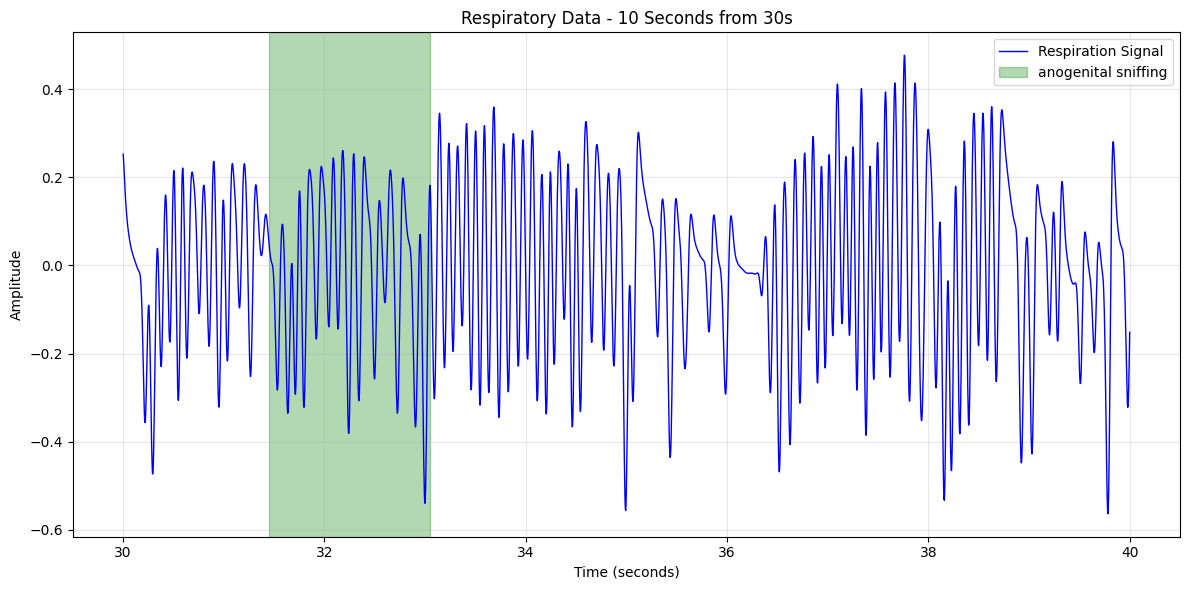

In [22]:
resp_plotting.resp_behavior_plot(resp_df, subj_11_c_resp_fs, start_time+30, duration=10)

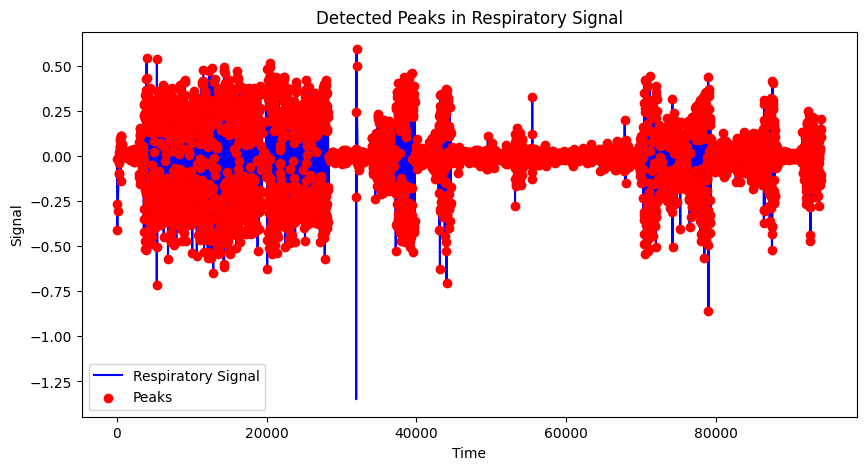

In [23]:
import signal_processing

peak_inds, peak_mags = signal_processing.peakfinder(resp_df['Respiration Value'])

# Create a new column in the DataFrame to mark detected peaks
resp_df['peak'] = 0
resp_df.loc[peak_inds.astype(int), 'peak'] = 1  # Mark peaks in the DataFrame

# Plot the signal with peaks
plt.figure(figsize=(10, 5))
plt.plot(resp_df.index, resp_df['Respiration Value'], label='Respiratory Signal', color='blue')
plt.scatter(resp_df.index[peak_inds.astype(int)], peak_mags, color='red', label='Peaks', zorder=3)
plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('Detected Peaks in Respiratory Signal')
plt.legend()
plt.show()

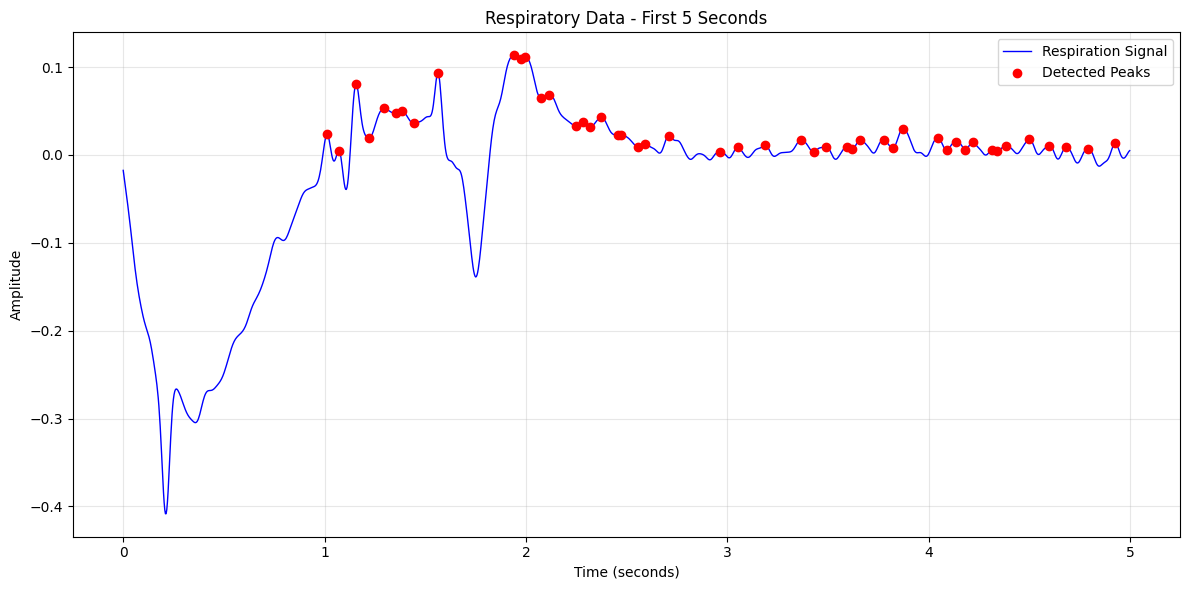

In [24]:
import importlib
importlib.reload(resp_plotting)

resp_plotting.final_resp_plot(resp_df, subj_11_c_resp_fs, start_time, duration=5, show_peaks=True, peak_sel=0.001, peak_thresh=0.003)

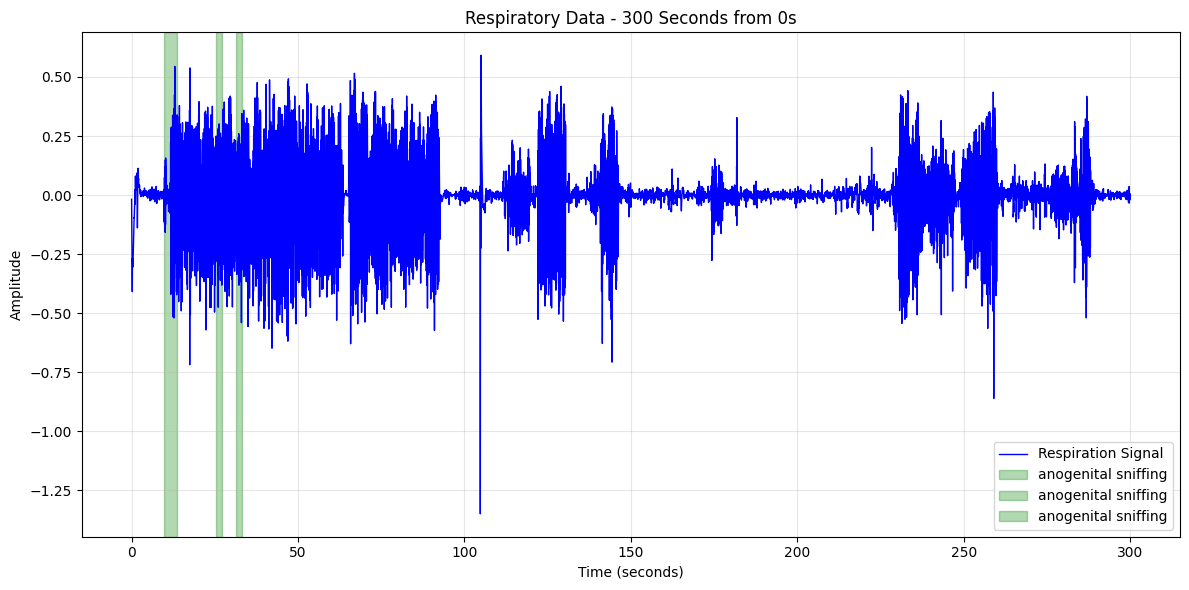

In [25]:
resp_plotting.resp_behavior_plot(resp_df, subj_11_c_resp_fs, start_time, duration=300)

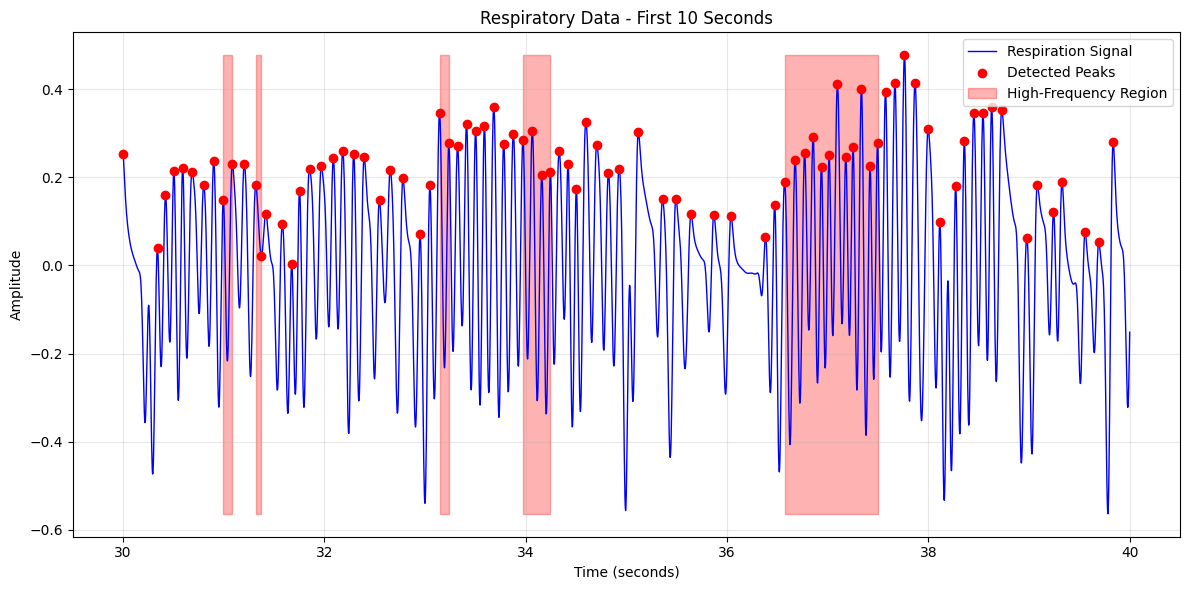

High-Frequency Regions (start, end): [(1.0125312, 1.0452991999999999), (2.2478848, 2.2839296), (3.7748736, 3.9550975999999998), (4.1353216, 4.3155456), (6.1800448, 6.209536), (6.3504384, 6.897664), (6.992691199999999, 7.0385664), (7.500595199999999, 7.759462399999999), (7.7987839999999995, 7.8381056), (7.9429631999999994, 7.9855616), (8.4115456, 8.4934656), (8.804761599999999, 8.8440832), (9.191424, 9.2274688), (9.315942399999999, 9.453567999999999), (9.4994432, 9.5387648), (9.5813632, 9.9221504), (10.1482496, 10.371072), (11.0198784, 11.213209599999999), (13.3070848, 13.5593984), (14.0181504, 14.195097599999999), (15.4959872, 15.879372799999999), (16.1185792, 16.4626432), (17.0164224, 17.232691199999998), (17.7143808, 17.8126848), (18.549964799999998, 18.969395199999997), (19.0185472, 19.3626112), (19.8148096, 20.073676799999998), (21.151744, 21.328691199999998), (21.6563712, 21.816934399999997), (21.8660864, 22.085632), (22.4395264, 22.695116799999997), (23.248896, 23.330816), (23.37

In [26]:
importlib.reload(signal_processing)
importlib.reload(resp_plotting)

high_freq_regions = signal_processing.find_high_frequency_regions(resp_df, subj_11_c_resp_fs, window_size=5,threshold_percentile=25)

resp_plotting.final_resp_plot2(resp_df, subj_11_c_resp_fs, start_time+30, duration=10, show_peaks=True, peak_sel=0.001, peak_thresh=0.003, show_high_freq_regions=True, high_freq_threshold_percentile=20)

print("High-Frequency Regions (start, end):", high_freq_regions)

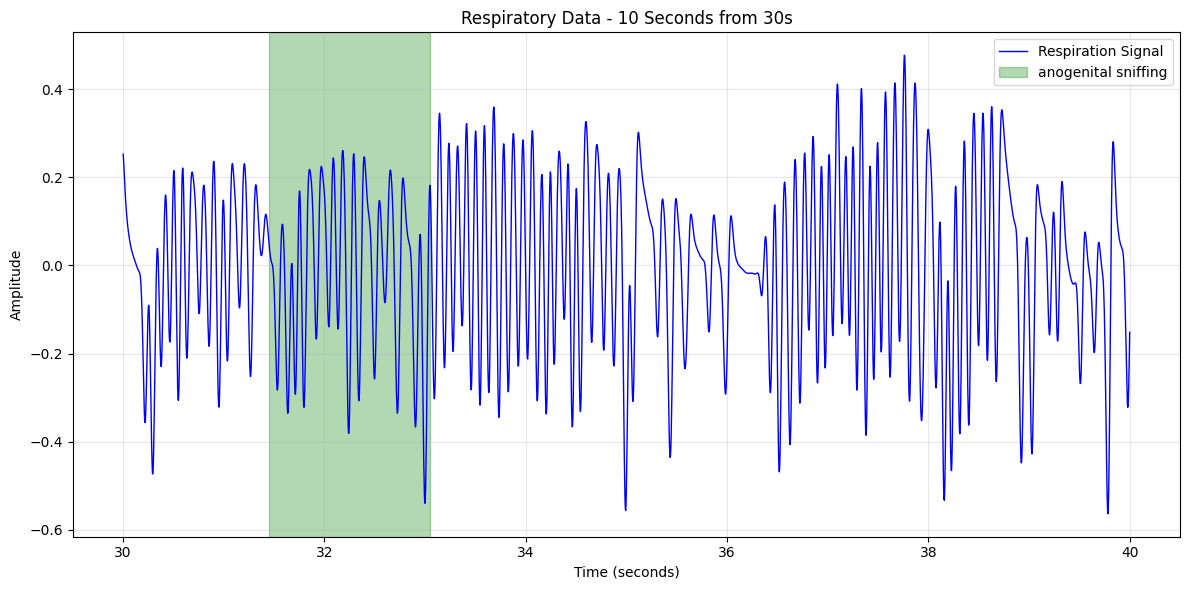

In [27]:
resp_plotting.resp_behavior_plot(resp_df, subj_11_c_resp_fs, start_time+30, duration=10)

In [28]:
resp_df

,Timestamp (s),Respiration Value,Behavioral Event,peak
0,0.000000,-0.017617,NaN,1
1,0.003277,-0.023248,NaN,0
2,0.006554,-0.028882,NaN,0
3,0.009830,-0.034538,NaN,0
4,0.013107,-0.040235,NaN,0
...,...,...,...,...
94139,308.474675,0.111142,NaN,0
94140,308.477952,0.101679,NaN,0
94141,308.481229,0.091953,NaN,0
94142,308.484506,0.082092,NaN,0


In [30]:
behavior_freq_changes = signal_processing.compute_frequency_change(resp_df, subj_11_c_resp_fs)

pd.set_option("display.float_format", "{:.2f}".format)  # Format numbers
display(behavior_freq_changes)  # Works in Jupyter

AttributeError: module 'signal_processing' has no attribute 'compute_frequency_change'